# Estimate background subtraction errors from trace stacks

This notebook loads the 05010 trace stack, aligns the background traces by centroid, and estimates a robust 1-sigma error per pixel using the median absolute deviation (MAD). It includes plots before/after alignment and residuals with the 1-sigma envelope.

In [1]:
%matplotlib widget

from pathlib import Path

import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt

from airglow import extraction_utils as extract_utils

/Users/parke/mamba/envs/stenv/lib/python3.13/site-packages/stsci/tools/nmpfit.py:8: UserWarning: NMPFIT is deprecated - stsci.tools v 3.5 is the last version to contain it.
  warnings.warn("NMPFIT is deprecated - stsci.tools v 3.5 is the last version to contain it.")
/Users/parke/mamba/envs/stenv/lib/python3.13/site-packages/stsci/tools/gfit.py:18: UserWarning: GFIT is deprecated - stsci.tools v 3.4.12 is the last version to contain it.Use astropy.modeling instead.
  warnings.warn("GFIT is deprecated - stsci.tools v 3.4.12 is the last version to contain it."


The following tasks in the stistools package can be run with TEAL:
   basic2d      calstis     ocrreject     wavecal        x1d          x2d


In [25]:
test_data_dir = extract_utils.find_test_data_dir()
trace_file = test_data_dir / "of9b05010_x1d_traces.fits"

if not trace_file.exists():
    raise FileNotFoundError(f"Missing trace stack: {trace_file}")

with fits.open(trace_file) as hdul:
    hdul.info()

    trace_table = hdul["TRACES"].data
    background_stack = extract_utils._get_column(trace_table, "background")
    traces = extract_utils._get_column(trace_table, "flux")
    wavelength = extract_utils._get_column(trace_table, "wavelength")
    y_positions = extract_utils._get_column(trace_table, "a2center")

    sci_table = hdul['SCI'].data
    sci_wavelength, = extract_utils._get_column(sci_table, "wavelength")
    sci_flux, = extract_utils._get_column(sci_table, "flux")
    sci_error, = extract_utils._get_column(sci_table, "error")

print(f"Loaded traces: {traces.shape}")

Filename: /Users/parke/Repos/airglow/test-data/of9b05010_x1d_traces.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     275   ()      
  1  SCI           1 BinTableHDU    157   1R x 19C   [1I, 1I, 1024D, 1024E, 1024E, 1024E, 1024E, 1024E, 1024E, 1024I, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1024E, 1E]   
  2  TRACES        1 BinTableHDU    136   54R x 20C   [1I, 1I, 1024D, 1024E, 1024E, 1024E, 1024E, 1024E, 1024E, 1024I, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1024E, 1E, 1B]   


Loaded traces: (54, 1024)


In [34]:
# Optionally limit traces by y windows (pixel coordinates).
# Example: y_windows = [(480, 540), (650, 700)]
y_windows = None
# y_windows = [(40, 150), (240, 340)]
y_windows = [(40, 160), (240, 750), (870, 960)]

result = extract_utils.estimate_background_sigma_from_traces(
    wavelength_stack=wavelength,
    trace_stack=traces,
    y_positions=y_positions,
    y_windows=y_windows,
)

wave = result["common_wavelength"]
sigma = result["aligned_sigma"]

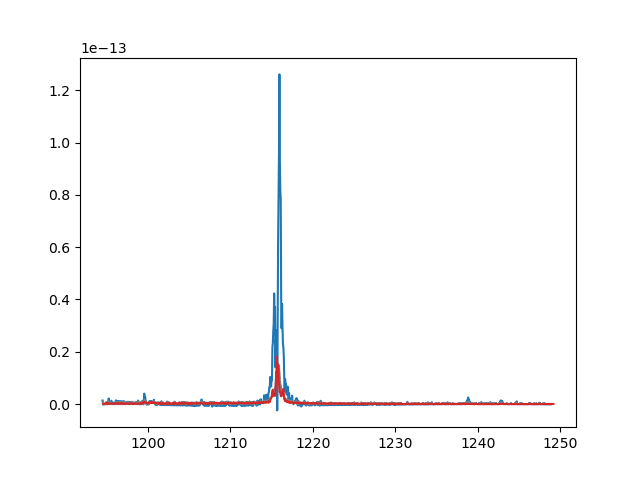

In [35]:
plt.figure()
plt.plot(sci_wavelength, sci_flux)
plt.plot(sci_wavelength, sci_error, color='tab:gray')
plt.plot(wave, sigma, color='tab:red')
